<a href="https://colab.research.google.com/github/haseebkhanmhk10-crypto/DeveloperHub-Corporation-internship-Data-Analysis-/blob/main/Task_3_Customer_Churn_Prediction_(Bank_Customers).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 3: Customer Churn Prediction (Bank Customers)

**Objective:** Identify customers who are likely to leave the bank using the Churn Modelling Dataset.

**Instructions:**

● Clean and prepare the dataset.

● Encode categorical features such as geography and gender.

● Train a classification model.

● Analyze feature importance to understand what influences churn.

### Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv('Churn_Modelling.csv')
print("Dataset loaded successfully.")


Dataset loaded successfully.


### Data Exploration

In [2]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print("\nDataFrame Information:")
df.info()


DataFrame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
print("\nDescriptive statistics of the dataset:")
display(df.describe())


Descriptive statistics of the dataset:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### Data Cleaning and Preprocessing

In [5]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])
print("Dropped 'RowNumber', 'CustomerId', and 'Surname' columns.")
display(df.head())


Dropped 'RowNumber', 'CustomerId', and 'Surname' columns.


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


#### Encoding Categorical Features

In [6]:
categorical_cols = ['Geography', 'Gender']

print("Unique values in 'Geography' before encoding:", df['Geography'].unique())
print("Unique values in 'Gender' before encoding:", df['Gender'].unique())

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

print("\nDataset after one-hot encoding categorical features:")
display(df.head())
print("\nUpdated DataFrame Information after encoding:")
df.info()


Unique values in 'Geography' before encoding: ['France' 'Spain' 'Germany']
Unique values in 'Gender' before encoding: ['Female' 'Male']

Dataset after one-hot encoding categorical features:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0



Updated DataFrame Information after encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  int64  
 10  Geography_Spain    10000 non-null  int64  
 11  Gender_Male        10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


### Model Training

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Defining features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

# Spliting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Data split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


Data split into training and testing sets successfully.
X_train shape: (8000, 11)
X_test shape: (2000, 11)
y_train shape: (8000,)
y_test shape: (2000,)


In [8]:
if 'X_train' in locals() and 'y_train' in locals():
    # Initialize and train the RandomForestClassifier
    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    print("RandomForestClassifier trained successfully.")
else:
    print("Error: Training data not available. Please ensure previous cells were executed.")


RandomForestClassifier trained successfully.


### Model Evaluation

In [9]:
if 'model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    y_pred = model.predict(X_test)

    # Evaluating the model
    print("Model Evaluation:")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print("\nConfusion Matrix:")
    display(pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))
else:
    print("Error: Model or test data not available. Please ensure previous cells were executed.")


Model Evaluation:
Accuracy: 0.8605

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.78      0.44      0.56       407

    accuracy                           0.86      2000
   macro avg       0.82      0.70      0.74      2000
weighted avg       0.85      0.86      0.84      2000


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,1542,51
Actual 1,228,179


### Feature Importance Analysis

Feature Importances:


,Feature,Importance
1,Age,0.248080
3,Balance,0.142801
7,EstimatedSalary,0.136935
0,CreditScore,0.134712
4,NumOfProducts,0.132607
2,Tenure,0.080375
6,IsActiveMember,0.036671
8,Geography_Germany,0.033974
10,Gender_Male,0.020489
5,HasCrCard,0.018779


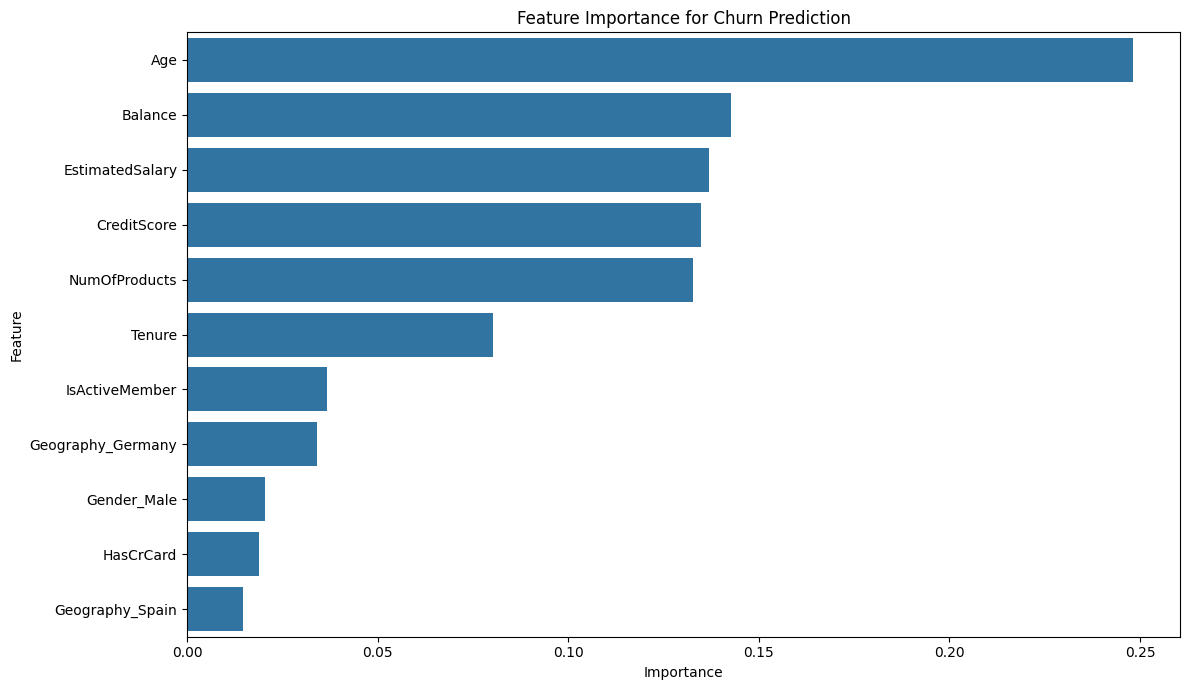

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'model' in locals() and 'X' in locals():
    feature_importances = model.feature_importances_

    features_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances
    }).sort_values(by='Importance', ascending=False)

    print("Feature Importances:")
    display(features_df)

    plt.figure(figsize=(12, 7))
    sns.barplot(x='Importance', y='Feature', data=features_df)
    plt.title('Feature Importance for Churn Prediction')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Error: Model or features (X) not available. Please ensure previous cells were executed.")


### Conclusion

This analysis aimed to predict customer churn in a banking dataset by performing the following steps:

1.  **Data Loading and Exploration**: Loaded the `Churn_Modelling.csv` dataset and explored its structure, data types, and descriptive statistics.
2.  **Data Preprocessing**: Cleaned the dataset by dropping irrelevant columns ('RowNumber', 'CustomerId', 'Surname') and encoded categorical features ('Geography', 'Gender') using one-hot encoding.
3.  **Model Training**: A `RandomForestClassifier` was trained on the prepared data, splitting it into training and testing sets (80/20 split).
4.  **Model Evaluation**: The model achieved an accuracy of **86.05%** on the test set. The classification report showed that while the model performs well in identifying non-churners (class 0), there is room for improvement in recalling actual churners (class 1), as indicated by the lower recall score for class 1 (0.44).
5.  **Feature Importance Analysis**: The feature importance plot revealed that **Age**, **EstimatedSalary**, and **CreditScore** were among the most influential factors in predicting customer churn. This suggests that these attributes play a significant role in a customer's decision to leave the bank.